In [12]:
using Pkg
Pkg.activate("../scripts/calval")
using IceFloeTracker
using Images
using DataFrames
using CSVFiles
using CairoMakie
using StatsBase

  Activating project at `~/Documents/research/calval_tgrs/scripts/calval`
  Activating project at `~/Documents/research/calval_tgrs/scripts/calval`


The filter floes method produces dataframes with floe properties and probabilities

In [3]:
# Load data
dataset = Watkins2026Dataset(;
    url="https://github.com/danielmwatkins/ice-floe-validation-dataset/",
    ref="v0.2",
    cache_dir="/tmp/Watkins2026",
    metadata_path="data/validation_dataset/validation_dataset.csv",
)

#### Run this to use the previously defined test/train split ####
prior_data = DataFrame(load("../data/train_test_split.csv"))
dataset.info[:, :training_sample] = parse.(Bool, prior_data[:, :training_sample])
dataset.info[:, :testing_sample] = parse.(Bool, prior_data[:, :testing_sample])
train_cases = filter(c -> c.training_sample, dataset) 
test_cases = filter(c -> c.testing_sample, dataset);

train_cases.info[:, :lookup_index] = 1:nrow(train_cases.info)
test_cases.info[:, :lookup_index] = 1:nrow(test_cases.info);

cluster_algo = IceDetectionBrightnessPeaksMODIS721(;
        band_7_max=0.16,
        possible_ice_threshold=0.6,
        join_method="union",
        minimum_prominence=0.01,
    )

cleanup_binary_params = (erosion_strel=strel_box((3, 3)), init_max_fill=100, conditional_max_fill=500
)
floe_splitting_params = (max_hole_fill=2000, max_distance=5, max_expand=3)

function clean_split_label(binary_mask, ice_mask, cloud_mask)
    return FSPipeline.dist_morph_split(
        FSPipeline.clean_binary_floes(binary_mask, ice_mask, cloud_mask; cleanup_binary_params...);
        floe_splitting_params...,
    )
end

# Workflows produce labeled arrays, not segmented images
function kmeans_workflow(preproc_gray, fc_masked, water_mask, ice_mask, cloud_mask; k=4, cluster_selection_algorithm=cluster_algo)
    masked_gray = apply_landmask(preproc_gray, water_mask)
    kmeans_result = kmeans_binarization(
        masked_gray, fc_masked; k=k, cluster_selection_algorithm=cluster_algo) .> 0
    return clean_split_label(kmeans_result, ice_mask, cloud_mask)
end

function adaptive_workflow(preproc_gray, land_mask, water_mask, ice_mask, cloud_mask; window_size=400, percentage=0)
    adaptive_result = binarize(preproc_gray, AdaptiveThreshold(; window_size=window_size, percentage=percentage)) .> 0
    apply_landmask!(adaptive_result, land_mask)
    apply_landmask!(adaptive_result, water_mask)
    return clean_split_label(adaptive_result .> 0, ice_mask, cloud_mask)    
end

adaptive_workflow (generic function with 1 method)

In [23]:
# Filter functions
function filter_floes(
    img_indexmap,
    coastal_buffer_mask,
    cloud_mask,
    falsecolor_image;
    min_floe_size=100,
    max_floe_size=90_000,
    boundary_radius=15,
    min_reflectance=0.4,
    min_circularity=0.3,
    min_contrast=0.01,
    filter_function=LogisticRegressionFilter,
    min_probability=0.5,
)
    # 1. Remove objects which overlap the coastal mask
    overlap = unique(img_indexmap[coastal_buffer_mask])
    indices = component_indices(img_indexmap)
    for L in overlap
        img_indexmap[indices[L]] .= 0
    end

    # 2. Remove objects outside the specified size bounds prior to extracting features.
    # This is important since the small features can cause problems in some feature
    # descriptors.
    remove_small_segments!(img_indexmap, min_floe_size)
    remove_large_segments!(img_indexmap, max_floe_size)

    # 3. Get object-wise properties
    results_df = regionprops_table(img_indexmap;
        properties=[:label, :area, :perimeter, :bbox, :centroid,
                    :major_axis_length, :minor_axis_length, :orientation]
    )
    # Return blank image if no floes remain
    nrow(results_df) == 0 && return results_df

    results_df[:, :length_scale] = results_df[:, :area] .^ 0.5
    results_df[:, :circularity] = 4 * π * results_df[:, :area] ./ results_df[:, :perimeter] .^ 2
    subset!(results_df, :circularity => r -> r .> min_circularity)
    nrow(results_df) == 0 && return results_df

    results_df[:, :cloud_fraction] =  (r -> mean(cloud_mask[indices[r]])).(results_df[:, :label])
    
    # mean reflectance
    segment_mean_reflectance = segment_mean(SegmentedImage(falsecolor_image, img_indexmap))
    b = [segment_mean_reflectance[L] for L in results_df[:, :label]]
    results_df[:, :b1_reflectance_mean] = blue.(b)
    results_df[:, :b7_reflectance_mean] = red.(b)
    results_df[:, :b2_reflectance_mean] = green.(b)
    
    subset!(results_df, :b1_reflectance_mean => r -> r .> min_reflectance)
    nrow(results_df) == 0 && return results_df
    
    # mean boundary reflectance
    b1 = blue.(falsecolor_image)
    bdry_indexmap = expand_labels(img_indexmap, boundary_radius) .- img_indexmap
    bdry_indices = component_indices(bdry_indexmap)
    bdry_labels = intersect(results_df[:, :label], unique(bdry_indexmap))
    b1_bdry_means = Dict(L => mean(b1[bdry_indices[L]]) for L in bdry_labels)
    for L ∈ results_df[:, :label]
        if L ∉ bdry_labels
            push!(b1_bdry_means, L => 0)
        end
    end
    results_df[:, :b1_reflectance_bdry_mean] = [b1_bdry_means[L] for L in results_df[:, :label]]
    results_df[:, :b1_bdry_contrast] = results_df[:, :b1_reflectance_mean] .- results_df[:, :b1_reflectance_bdry_mean]
    subset!(results_df, :b1_bdry_contrast => r -> r .> min_contrast)
    nrow(results_df) == 0 && return results_df

    results_df[:, :probability] .= filter_function(results_df)
    subset!(results_df, :probability => r -> r .> min_probability)

    return results_df
end

# TODO: dmw -- this could be a struct / functor pair, so the filter takes a FloeProbabilityFunction rather than needing to be LogisticRegression
"""
    LogisticRegressionFilter(df; coefs)

Compute the probability for each DataFrameRow using the logistic function
with coefficients defined in `coefs`. Names should include "intercept" and
names of columns in `df`.

"""
function LogisticRegressionFilter(df;
    coefs = Dict(
        "intercept"           => -19.3361,
        "length_scale"        => 0.0589,
        "circularity"         => 13.399,
        "b1_reflectance_mean" => 9.294,
        "b1_bdry_contrast"    => 3.062,
        "b7_reflectance_mean" => -1.179,
        )
    )
    colnames = [x for x in keys(coefs)]
    b = [x for x in values(coefs)]
    df[:, :intercept] .= 1;
    return 1 ./ (1 .+ exp.(-Matrix(df[:, colnames]) * b))
end


LogisticRegressionFilter

In [5]:
case = train_cases

function fill_missing!(cases; template=Gray.(zeros(Bool, (400, 400))))
    for (idx, img) in enumerate(cases)
        if isnothing(img)
            cases[idx] = template
        end
    end
end

cloud_mask_function = Watkins2026CloudMask(
    band_7_threshold=0.16,
    band_2_threshold=0.34,
    opening_strel=strel_disk(3),
    dilation_strel=strel_disk(2)
)

ice_mask_function = IceDetectionBrightnessMidpoint(; minimum_reflectance=0.45)

@time begin
    tc_imgs = modis_truecolor.(case)
    fc_imgs = modis_falsecolor.(case)
    land_masks = modis_landmask.(case) .|> r -> r .> 0
    cloud_masks = cloud_mask_function.(fc_imgs)
    coastal_buffers = create_coastal_buffer_mask.(land_masks, [strel_box((25,25))])
    
    # joint_mask_buffers = ((x, y) -> x .|| y).(coastal_buffers, cloud_masks)
    
    # Mask images before k-means, preliminary ice mask application
    tc_masked = apply_landmask.(tc_imgs, land_masks)
    fc_masked = apply_landmask.(fc_imgs, land_masks)
    fc_buffered = apply_landmask.(fc_imgs, coastal_buffers)
    band_1 = fc_masked .|> r -> Gray.(blue.(r))
    ice_masks = ice_mask_function.(band_1) .|> r -> r .> 0
    # Masks have to be a full partition for this to work. So if the coastal buffer is used to make
    # the ice mask, it also must be used for the land mask here.
    water_masks = ((x, y, z) -> .!x .&& .!y .&& .!z).(land_masks, cloud_masks, ice_masks)
    
    # reference images
    binary_floes = validated_binary_floes.(case)
    fill_missing!(binary_floes)
end
nothing

  8.985842 seconds (46.27 M allocations: 4.038 GiB, 15.32% gc time, 59.56% compilation time: 4% of which was recompilation)


In [6]:
preproc_function = FSPipeline.Preprocess(
    diffusion_algorithm = PeronaMalikDiffusion(; λ=0.1, K=0.1, niters=5, g="exponential"),
    adapthisteq_params = (nbins=256, rblocks=2, cblocks=2, clip=5),
    unsharp_mask_params = (radius=50, amount=0.3, threshold=0.01),
)
tiles = get_tiles(tc_imgs[1], (400, 400)) # single tile
preproc_gray = preproc_function.(tc_imgs, land_masks, [tiles]);

In [7]:
adapt_labels = adaptive_workflow.(preproc_gray, land_masks, water_masks, ice_masks, cloud_masks; window_size=200, percentage=0);
kmeans_labels = kmeans_workflow.(preproc_gray, fc_buffered, water_masks, ice_masks, cloud_masks);

In [27]:
idx = 1
df_a = filter_floes(adapt_labels[idx],
        coastal_buffers[idx],
        cloud_masks[idx],
        fc_imgs[idx]; min_probability=0
)
df_k = filter_floes(kmeans_labels[idx],
        coastal_buffers[idx],
        cloud_masks[idx],
        fc_imgs[idx]
);

In [28]:
df_a

Row,area,col_centroid,label,major_axis_length,max_col,max_row,min_col,min_row,minor_axis_length,orientation,perimeter,row_centroid,length_scale,circularity,cloud_fraction,b1_reflectance_mean,b7_reflectance_mean,b2_reflectance_mean,b1_reflectance_bdry_mean,b1_bdry_contrast,intercept,probability
,Int64,Any,Int64,Any,Int64,Int64,Int64,Int64,Any,Any,Float64,Any,Float64,Float64,Float64,Float32,Float32,Float32,Float64,Float64,Int64,Float64
1,345,147.846,9,25.398,161,179,135,158,18.94,1.54468,86.0833,166.928,18.5742,0.585048,1.0,0.692028,0.636899,0.688152,0.675241,0.0167871,1,0.00927773
2,174,163.5,11,17.6613,172,186,155,172,12.9693,-1.15358,55.5269,178.736,13.1909,0.709173,1.0,0.663465,0.633017,0.667297,0.638812,0.0246537,1,0.0276111
3,2069,203.277,12,79.9815,235,234,172,169,36.5764,0.817215,276.321,200.733,45.4863,0.34052,1.0,0.509018,0.524088,0.510787,0.308504,0.200514,1,0.000631084
4,131,187.267,13,18.4269,195,167,178,157,10.1236,1.55627,49.4558,162.137,11.4455,0.673048,1.0,0.587666,0.578327,0.594582,0.41165,0.176017,1,0.013062
5,584,212.233,17,32.9396,229,32,199,5,24.9933,-1.36484,116.326,18.4606,24.1661,0.542338,0.44863,0.711268,0.112382,0.667486,0.427303,0.283965,1,0.0356258


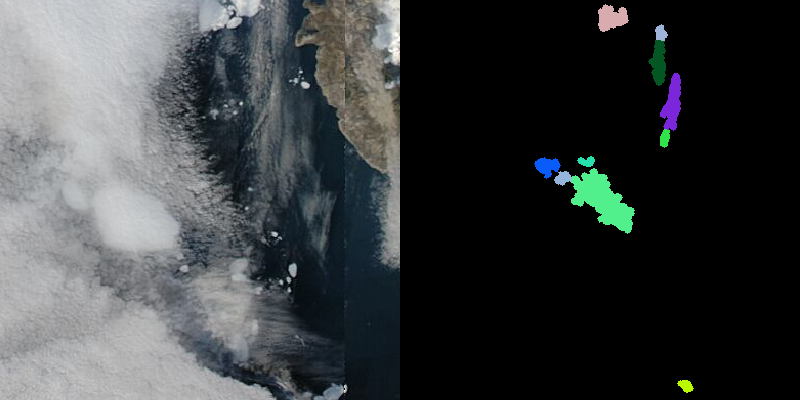

In [32]:
mosaicview(tc_imgs[idx], view_seg_random(SegmentedImage(fc_imgs[idx], adapt_labels[idx])), nrow=1)

# Steps and questions
1. Stages of selection covering the bases?
  1. Good agreement from both -> select the pair that has high similarity, then favor probability
  2. Poor agreement -> loop through floes, select floes that are highest probability in the comparison